Train Accuracy : 1.0000
Test Accuracy  : 0.9561

Confusion Matrix:
[[46  3]
 [ 2 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        49
           1       0.95      0.97      0.96        65

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.96       114
weighted avg       0.96      0.96      0.96       114



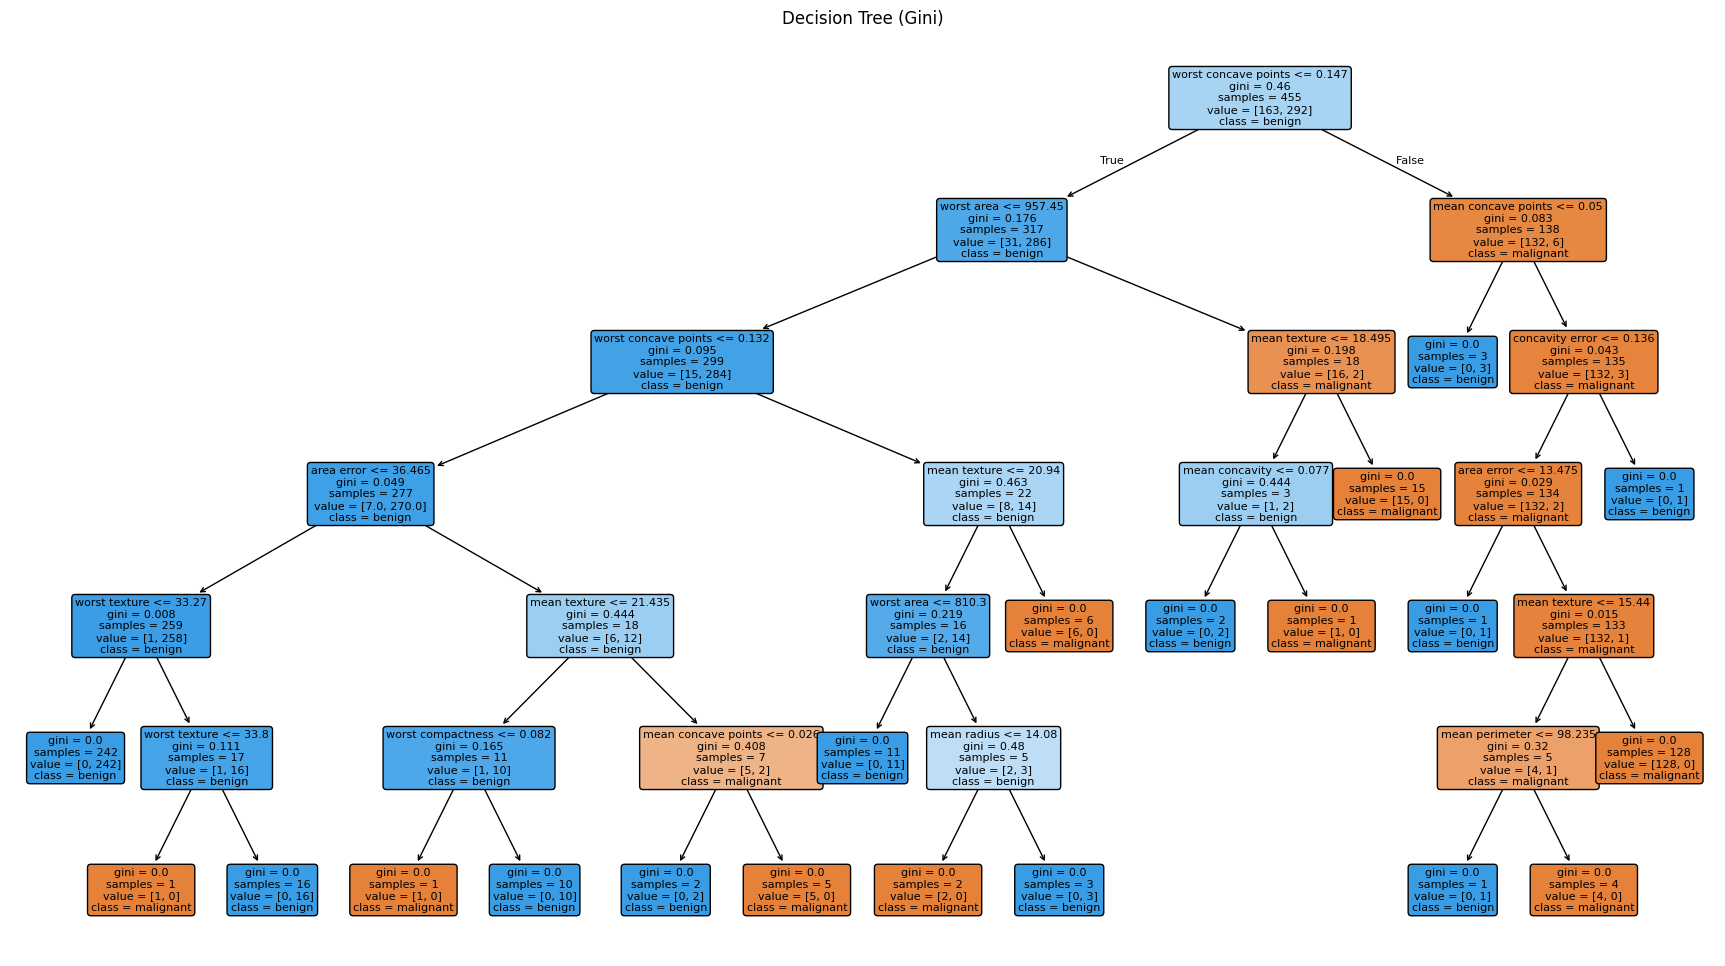

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

# Create Decision Tree
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Train Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

# Test Accuracy
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Decision Tree
plt.figure(figsize=(22,12))
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (Gini)")
plt.show()

Train Accuracy : 1.0000
Test Accuracy  : 0.9474

Confusion Matrix:
[[63  6]
 [ 3 99]]


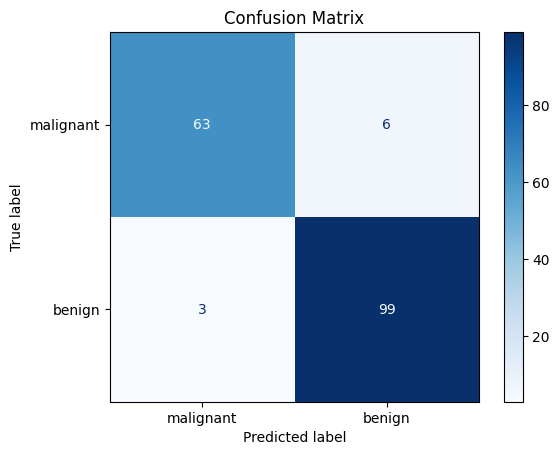


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        69
           1       0.94      0.97      0.96       102

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



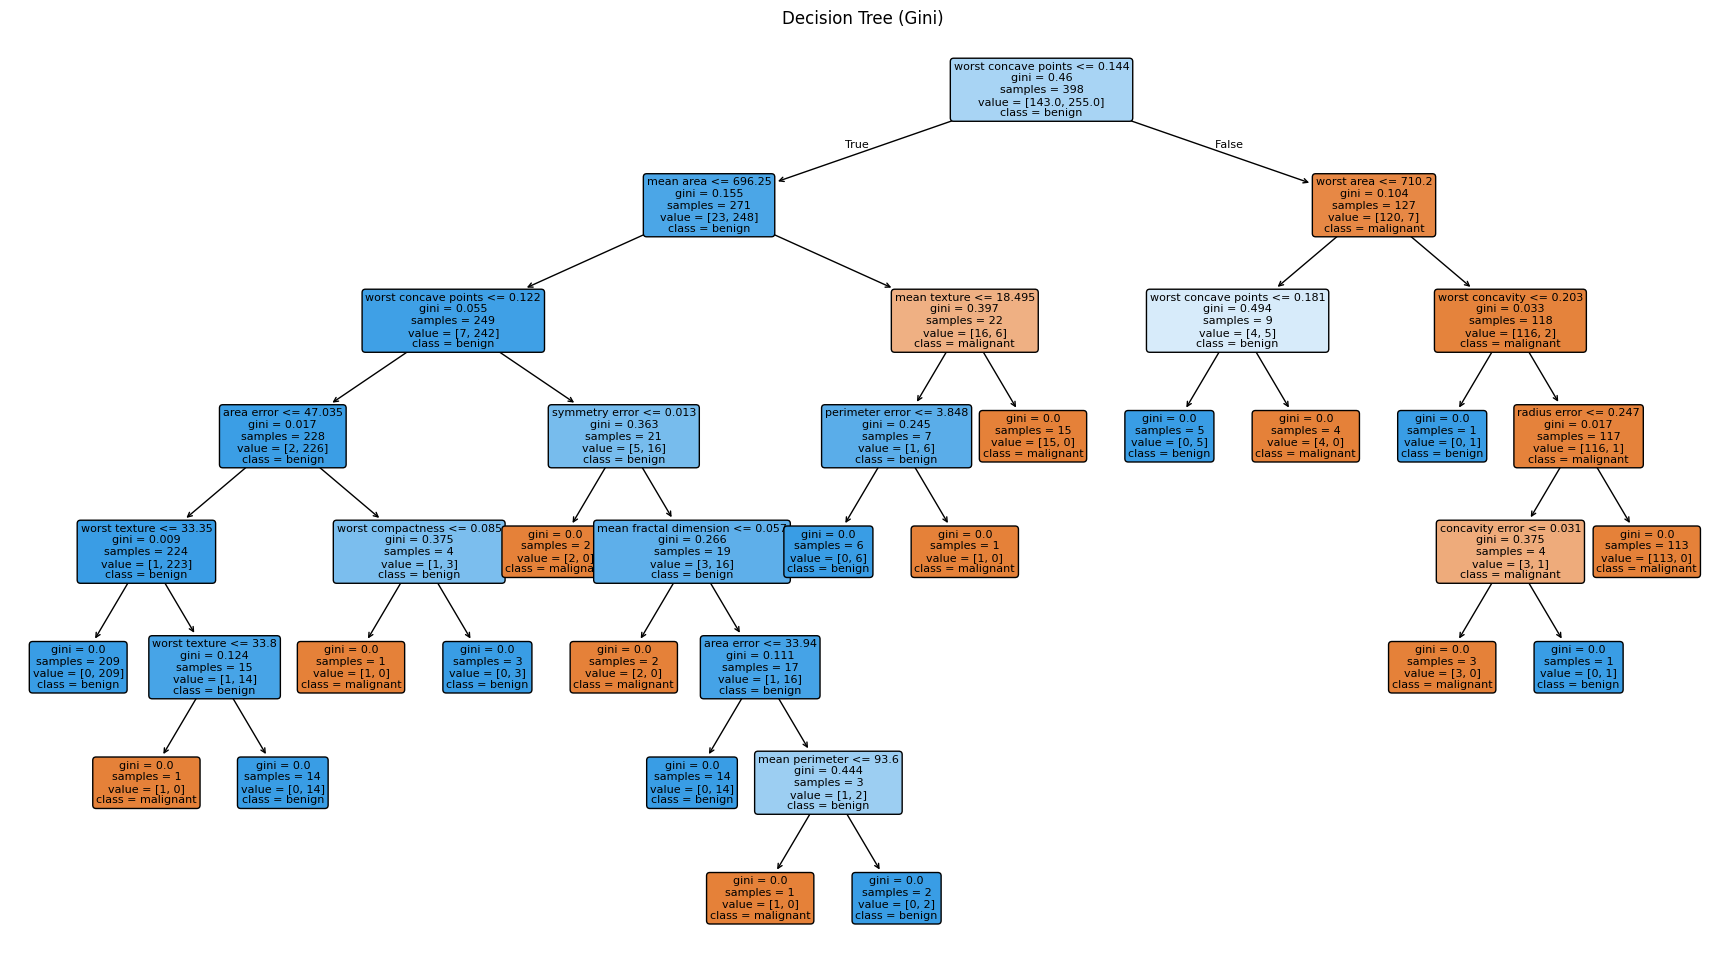

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=100
)

# Create and Train Model
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Decision Tree
plt.figure(figsize=(22,12))
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (Gini)")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for DecisionTreeClassifier
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 8], # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# 'cv=5' means 5-fold cross-validation
# 'scoring="accuracy"' specifies the metric to optimize
# 'n_jobs=-1' uses all available processors
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

Starting GridSearchCV...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
GridSearchCV completed.


Best parameters found: {'criterion': 'gini', 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation accuracy: 0.9371518987341773

Test Accuracy of the tuned model: 0.9415

Confusion Matrix for Tuned Model:
[[64  5]
 [ 5 97]]


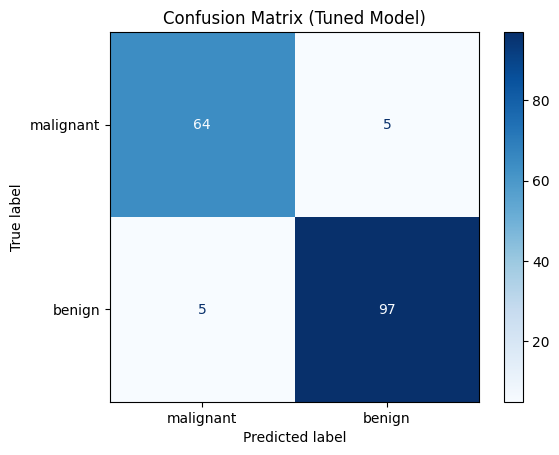


Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        69
           1       0.95      0.95      0.95       102

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [ ]:
# Print the best parameters found by GridSearchCV
print("Best parameters found:", grid_search.best_params_)

# Print the best cross-validation score
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best estimator (model) from GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_test_pred_tuned = best_model.predict(X_test)
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)

print(f"\nTest Accuracy of the tuned model: {test_acc_tuned:.4f}")

# Confusion Matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
print("\nConfusion Matrix for Tuned Model:")
print(cm_tuned)

# Display Confusion Matrix for the tuned model
from sklearn.metrics import ConfusionMatrixDisplay
disp_tuned = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=data.target_names
)

disp_tuned.plot(cmap="Blues")
plt.title("Confusion Matrix (Tuned Model)")
plt.show()

# Classification Report for the tuned model
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_test_pred_tuned))

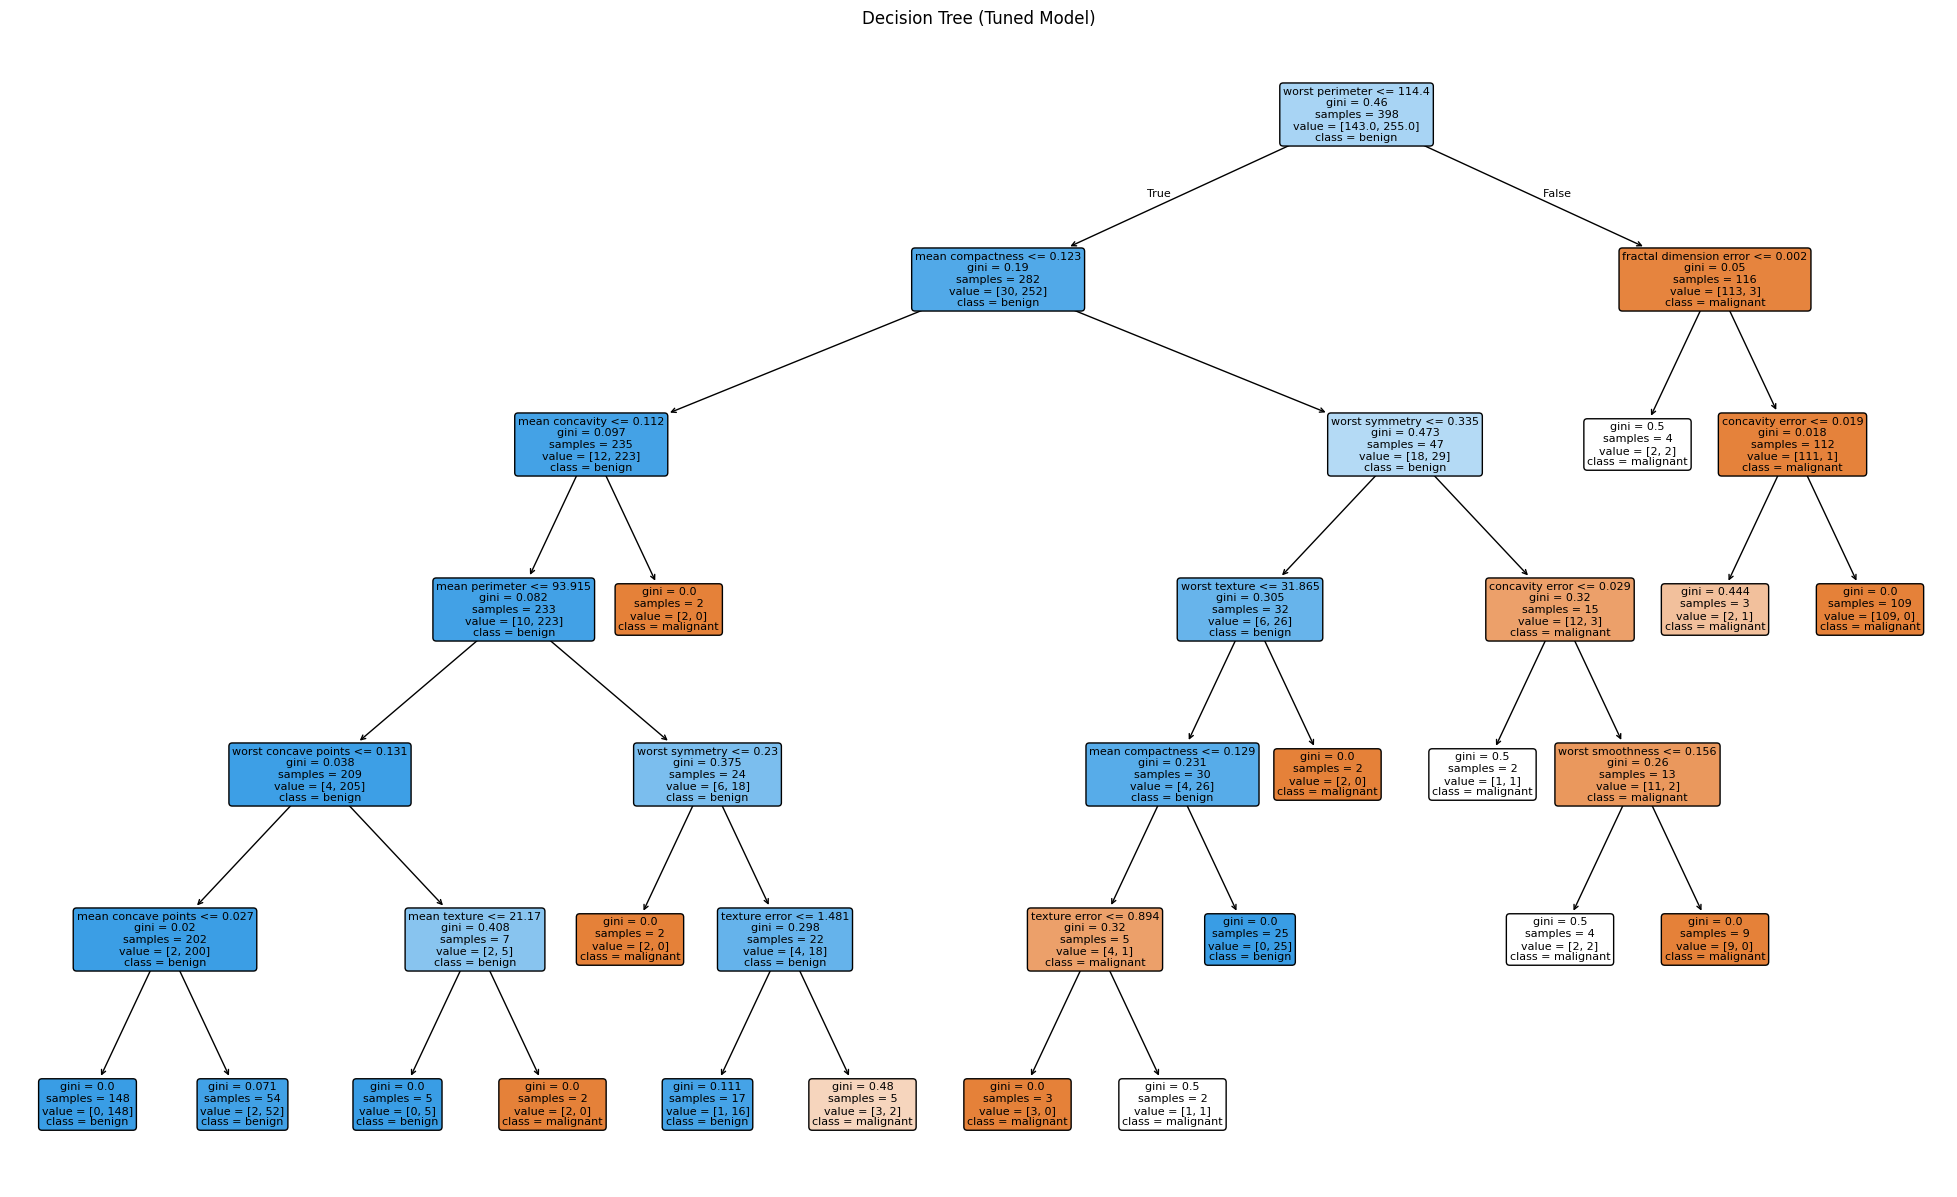

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot Decision Tree of the best model
plt.figure(figsize=(25, 15))
plot_tree(
    best_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (Tuned Model)")
plt.show()

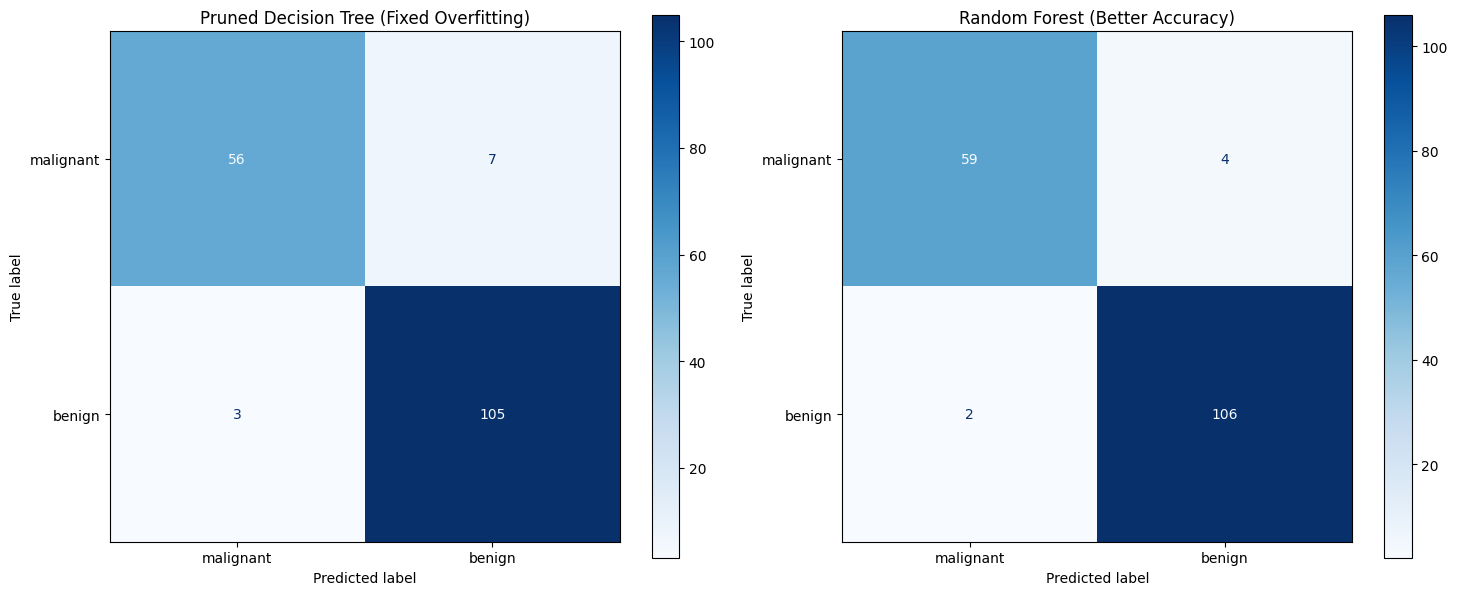

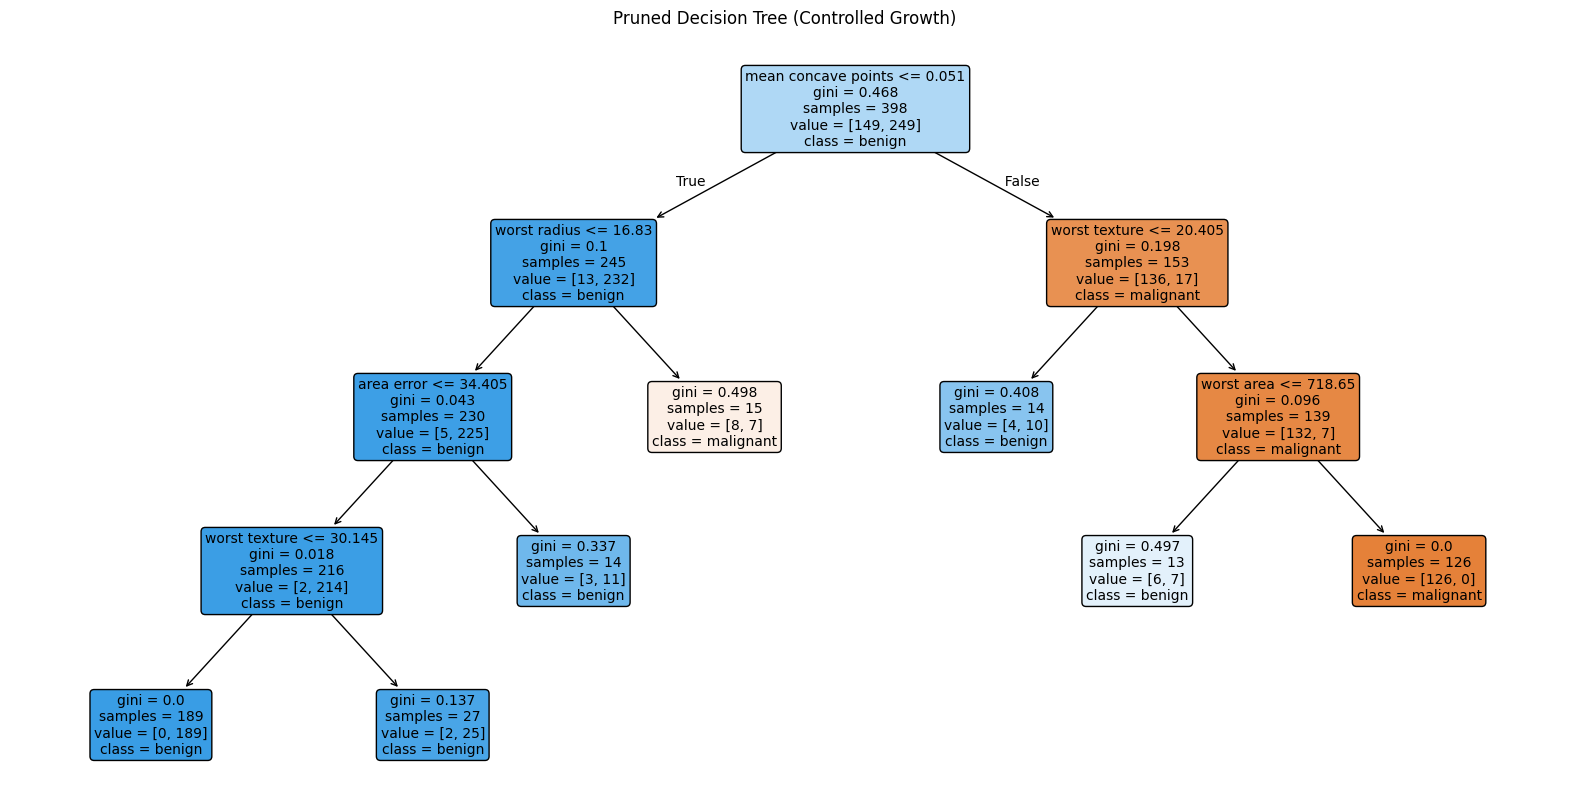

--- Pruned Decision Tree Performance ---
              precision    recall  f1-score   support

   malignant       0.95      0.89      0.92        63
      benign       0.94      0.97      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


--- Random Forest Performance ---
              precision    recall  f1-score   support

   malignant       0.97      0.94      0.95        63
      benign       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# 1. Dataset Load Karna (tumhare features ke hisaab se yeh standard cancer dataset hai)
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Train-Test Split (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==============================================================
# FIX 1: Pruned Decision Tree (Overfitting ko rokne ke liye)
# ==============================================================
# max_depth=4 aur min_samples_leaf=10 tree ko unnecessarily grow hone se rokenge
pruned_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
pruned_tree.fit(X_train, y_train)

# ==============================================================
# FIX 2: Random Forest (Professional Upgrade)
# ==============================================================
# Yeh 100 chote trees banayega, jisse False Negatives aur kam ho jayenge
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# ==============================================================
# Visualizations (Colab Outputs)
# ==============================================================

# A. Confusion Matrices plot karna
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_estimator(pruned_tree, X_test, y_test,
                                      display_labels=['malignant', 'benign'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Pruned Decision Tree (Fixed Overfitting)')

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test,
                                      display_labels=['malignant', 'benign'],
                                      cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest (Better Accuracy)')

plt.tight_layout()
plt.show()

# B. Naya Pruned Decision Tree plot karna
plt.figure(figsize=(20, 10))
plot_tree(pruned_tree,
          feature_names=data.feature_names,
          class_names=['malignant', 'benign'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Pruned Decision Tree (Controlled Growth)")
plt.show()

# C. Quick Performance Report
print("--- Pruned Decision Tree Performance ---")
print(classification_report(y_test, pruned_tree.predict(X_test), target_names=['malignant', 'benign']))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_model.predict(X_test), target_names=['malignant', 'benign']))

In [ ]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0